<a href="https://colab.research.google.com/github/pavi020/Traffic-Volume-Prediction-Regression/blob/main/TRAFFIC_VOLUME_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Traffic Volume Prediction Using Regression

The objective of this project is to develop a machine learning regression model that predicts traffic volume based on weather conditions, holidays, and time-related factors. Historical traffic and weather data are analyzed to identify patterns influencing road usage. A Linear Regression model is trained and evaluated to estimate traffic volume accurately





###Data loading and initial checking

This code cell imports the `pandas` library, which is essential for data manipulation and analysis in Python. It then reads the `Metro_Interstate_Traffic_Volume.csv` file into a pandas DataFrame called `df`. Finally, it displays the first 5 rows of the DataFrame using `df.head()` to provide a quick preview of the data structure and content.

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Metro_Interstate_Traffic_Volume.csv")
df.head()


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


This cell provides an initial overview of the dataset. It prints:
- The total number of rows and columns using `df.shape`.
- The data types of each column using `df.dtypes`.
- The count of missing values for each column using `df.isnull().sum()`.
- A statistical summary of the numerical columns (count, mean, std, min, 25%, 50%, 75%, max) using `df.describe()`.

In [ ]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")
print(df.dtypes)
missing_values = df.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")
# Perform statistical analysis
df.describe()


The dataset has 48204 rows and 9 columns
traffic_volume           int64
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
dtype: object
Missing values in each column:
traffic_volume             0
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
dtype: int64


,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231
std,1986.860670,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


#Data visualization

This code cell generates a histogram to visualize the distribution of the `traffic_volume` column.
- `matplotlib.pyplot` and `seaborn` are imported for plotting.
- `plt.figure(figsize=(10,6))` sets the size of the plot.
- `sns.histplot(df['traffic_volume'], kde=True)` creates the histogram, with `kde=True` adding a Kernel Density Estimate curve for a smoother representation of the distribution.
- `plt.title()` sets the title, and `plt.show()` displays the plot.

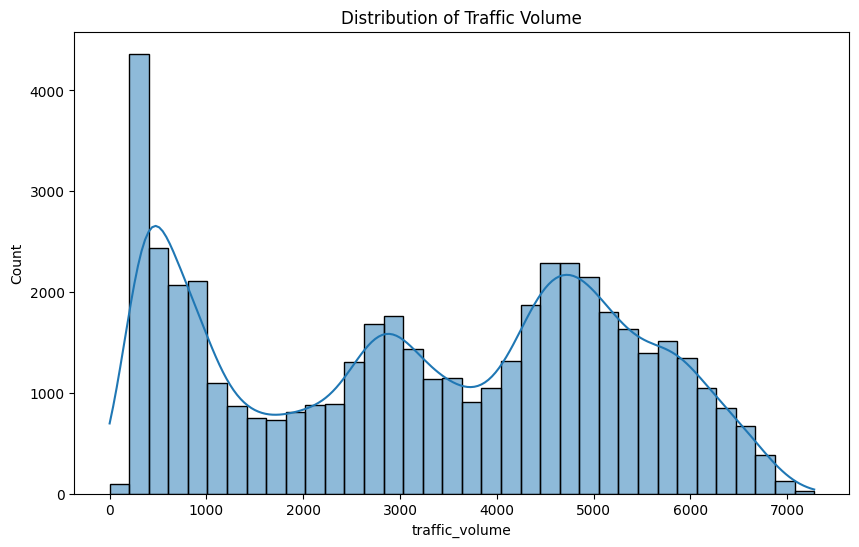

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df['traffic_volume'], kde=True)
plt.title('Distribution of Traffic Volume')
plt.show()



This cell creates a countplot to show the frequency of different `weather_main` conditions in the dataset.
- `sns.countplot(x='weather_main', data=df)` generates the plot.
- `plt.title()` sets the title.
- `plt.xticks(rotation=90)` rotates the x-axis labels to prevent overlap, making them more readable.
- `plt.show()` displays the plot.

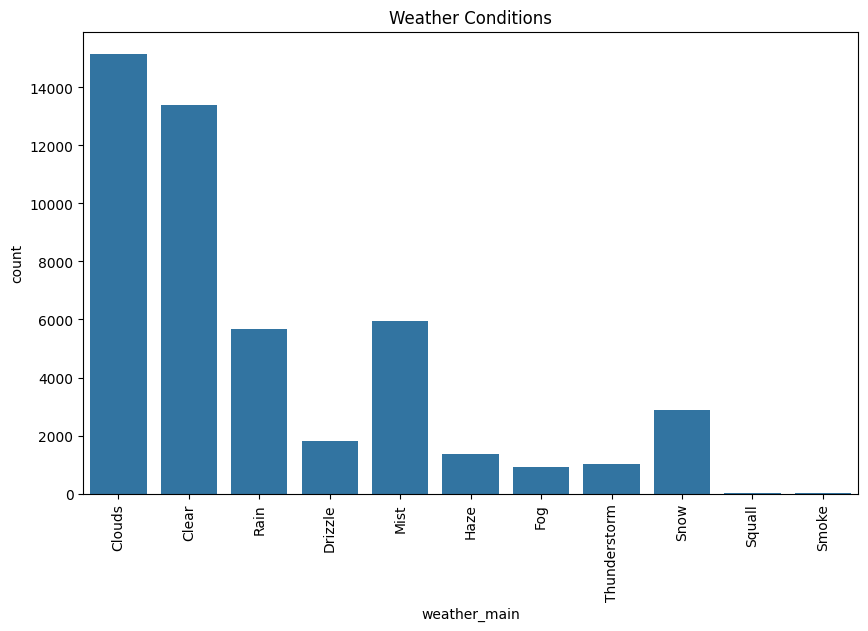

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='weather_main', data=df)
plt.title('Weather Conditions')
plt.xticks(rotation=90)
plt.show()

This code cell generates a scatter plot to visualize the relationship between `temp` (temperature) and `traffic_volume`.
- `sns.scatterplot(x='temp', y='traffic_volume', data=df)` creates the scatter plot.
- `plt.title()` sets the title, and `plt.show()` displays the plot. This helps in understanding if there's any correlation or pattern between temperature and the amount of traffic.

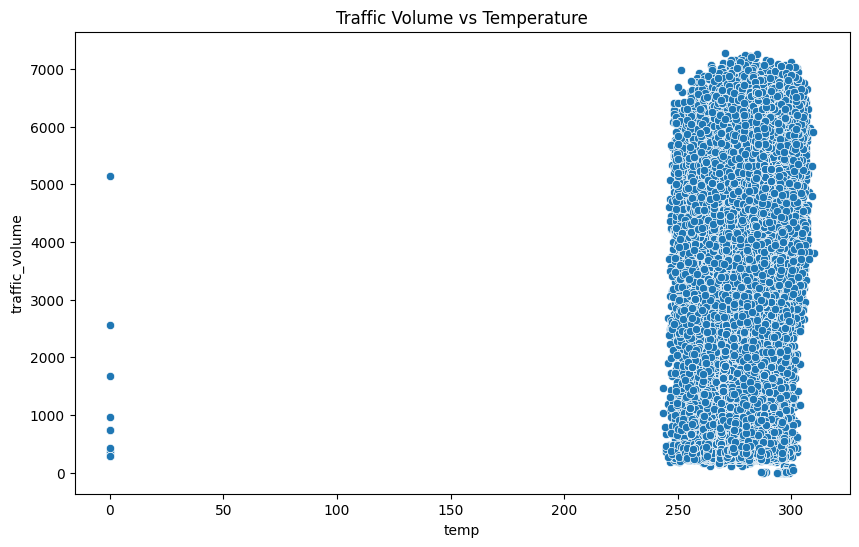

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='temp', y='traffic_volume', data=df)
plt.title('Traffic Volume vs Temperature')
plt.show()


###Feature engineering

This cell performs feature engineering on the `date_time` column.
- `df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')` converts the `date_time` column from a string (object) type to a datetime object, enabling easier extraction of temporal features.
- New columns `year`, `month`, `day`, and `hour` are then extracted from the `date_time` column using the `.dt` accessor, which is useful for time-series analysis and creating features for the model.

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour

This cell performs one-hot encoding on the categorical features: `weather_main`, `weather_description`, and `holiday`.
- `pd.get_dummies()` converts these categorical columns into numerical format, where each unique category becomes a new binary column (0 or 1). This is a necessary step as machine learning models typically require numerical input.

###Data Preprocessing

In [ ]:
df = pd.get_dummies(df, columns=['weather_main', 'weather_description', 'holiday'])

This code cell performs feature scaling on selected numerical columns using `StandardScaler` from `sklearn.preprocessing`.
- `StandardScaler` transforms the data to have a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms, especially those that are sensitive to the scale of the input features (like linear regression and gradient descent-based algorithms), as it helps prevent features with larger values from dominating the learning process.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['temp', 'rain_1h', 'snow_1h', 'clouds_all']] = scaler.fit_transform(df[['temp', 'rain_1h', 'snow_1h', 'clouds_all']])

###Model Training

This cell prepares the data for model training by splitting it into features (X) and target (y), and then further dividing these into training and testing sets.
- `X = df.drop(['traffic_volume', 'date_time'], axis=1)` defines the feature set `X` by dropping the `traffic_volume` (the target variable) and `date_time` (which has been converted into other features) columns.
- `y = df['traffic_volume']` defines the target variable `y` as `traffic_volume`.
- `train_test_split(X, y, test_size=0.2, random_state=42)` splits the data: 80% for training and 20% for testing. `random_state` ensures reproducibility of the split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define the features and the target
X = df.drop(['traffic_volume', 'date_time'], axis=1)
y = df['traffic_volume']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell initializes and trains a `LinearRegression` model.
- `model = LinearRegression()` creates an instance of the Linear Regression model.
- `model.fit(X_train, y_train)` trains the model using the training features (`X_train`) and their corresponding target values (`y_train`). During this process, the model learns the relationships between the features and the target variable.

In [ ]:
model= LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

LinearRegression()

This cell evaluates the performance of the trained `LinearRegression` model using several common regression metrics.
- `y_pred = model.predict(X_test)` generates predictions on the unseen test data.
- `mean_absolute_error`, `mean_squared_error`, and `np.sqrt(mse)` are used to calculate MAE, MSE, and RMSE, respectively. These metrics quantify how close the model's predictions are to the actual values in the test set.

###Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict on the testing data
y_pred = model.predict(X_test)

# Calculate MAE, MSE, and RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 1610.913538299117
Mean Squared Error (MSE): 3337723.2582683107
Root Mean Squared Error (RMSE): 1826.9436932396989


This cell analyzes the residuals (the differences between actual and predicted values) of the model.
- `residuals = y_test - y_pred` calculates the residuals.
- `sns.histplot(residuals, kde=True)` plots a histogram of these residuals, with a Kernel Density Estimate. Analyzing the distribution of residuals can provide insights into the model's performance and assumptions. For a good model, residuals often appear normally distributed around zero.

###Residuals

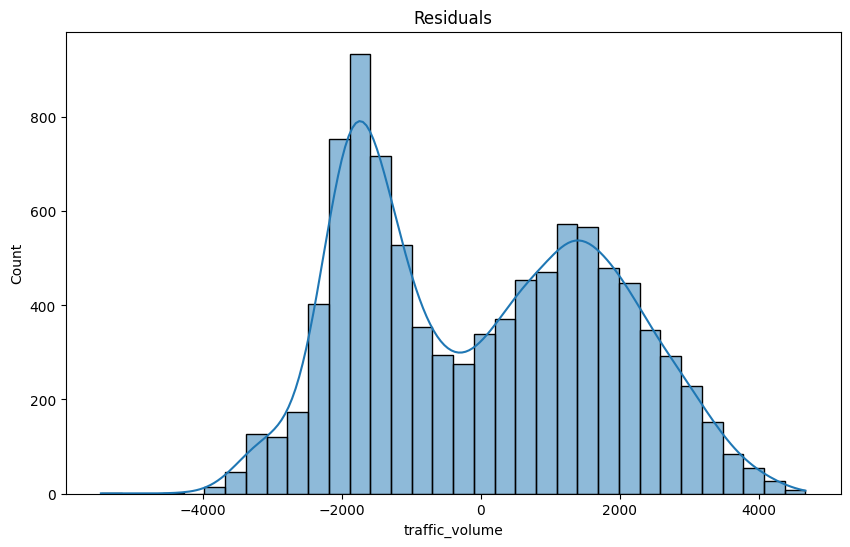

In [ ]:
residuals = y_test - y_pred

# Plot the residuals
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True)
plt.title('Residuals')
plt.show()